In [2]:

!pip install tensorflow==2.12.0
!pip install keras

Number of accelerators: 1
Found 35000 files belonging to 3 classes.
Found 900 files belonging to 3 classes.
Found 900 files belonging to 3 classes.
Classes: ['Cescospora Leaf Spot', 'Golden Mosaic', 'Healthy Leaf']


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


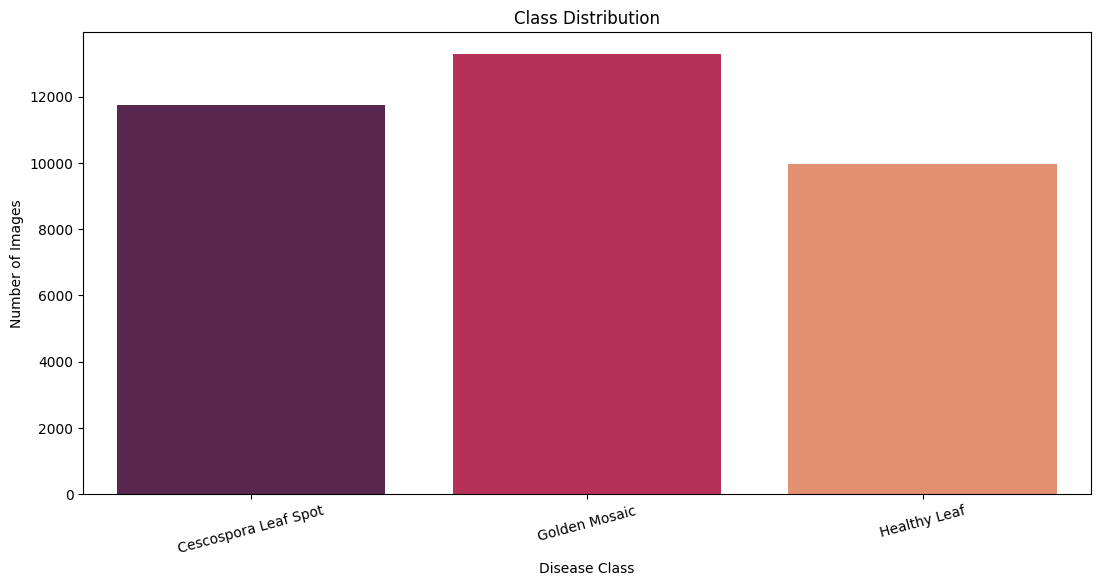


Class Weights:
Cescospora Leaf Spot: 0.99
Golden Mosaic: 0.88
Healthy Leaf: 1.17


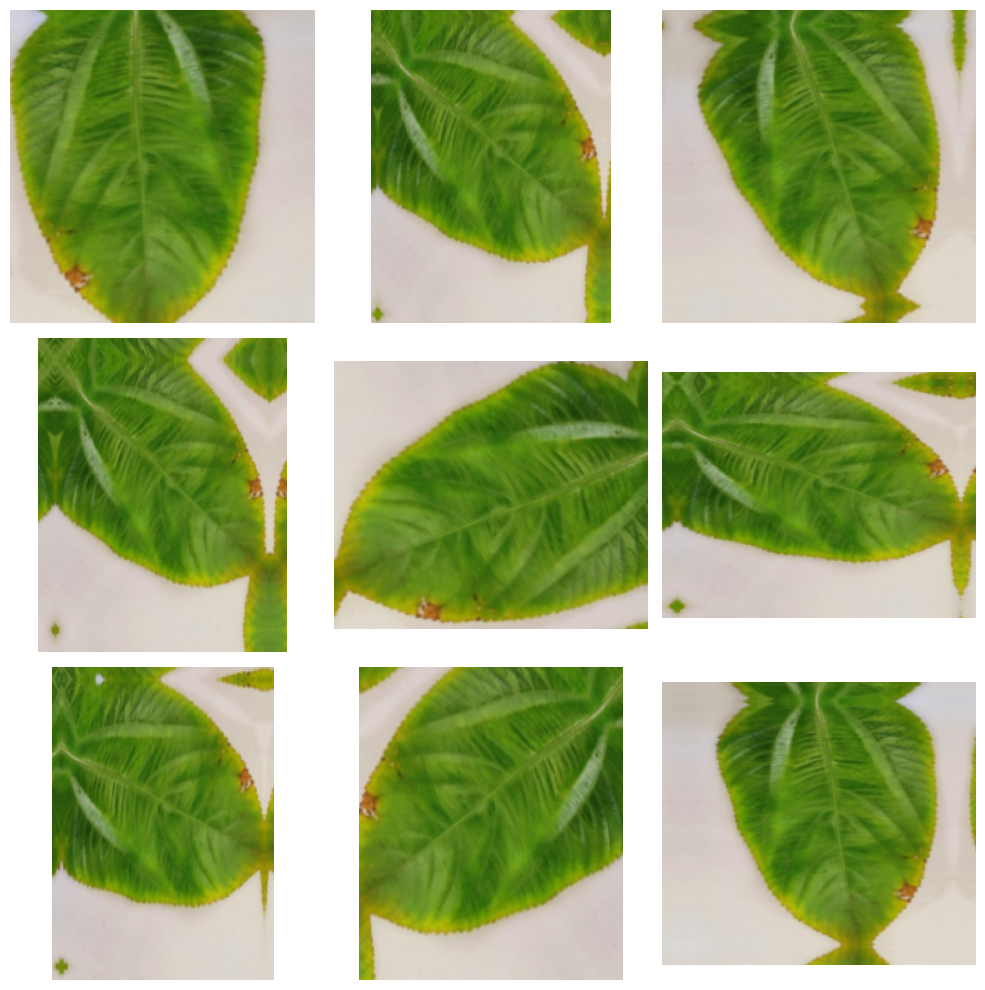

83683744/83683744 [==============================] - 3s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 xception (Functional)       (None, 7, 7, 2048)        20861480  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               262272    
                                                                 
 dense_1 (Dense)             (None, 3)                 387       
                                                                 
Total params: 21,124,139
Trainable params: 262,659
Non-trainab

KeyboardInterrupt: 

In [5]:
# ====================== IMPORTS ===========================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob as gb
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import mixed_precision

# ====================== STRATEGY SETUP ===========================
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
except:
    strategy = tf.distribute.get_strategy()

print("Number of accelerators:", strategy.num_replicas_in_sync)

# ====================== MIXED PRECISION ===========================
mixed_precision.set_global_policy('mixed_float16')

# ====================== CONSTANTS ===========================
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 10
SEED = 42

# ====================== DIRECTORIES ===========================
base_dir = "/kaggle/input/jute-leaf-disease-dataset"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# ====================== LOAD DATASETS ===========================
train_dataset = image_dataset_from_directory(
    train_dir,
    shuffle=True,
    labels='inferred',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=SEED
)

validation_dataset = image_dataset_from_directory(
    val_dir,
    shuffle=True,
    labels='inferred',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=SEED
)

test_dataset = image_dataset_from_directory(
    test_dir,
    shuffle=False,
    labels='inferred',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=SEED
)

class_names = train_dataset.class_names
print("Classes:", class_names)

# ====================== CLASS DISTRIBUTION ===========================
data_imbalance = []
for class_folder in class_names:
    file_list = gb.glob(os.path.join(train_dir, class_folder, '*.*'))
    data_imbalance.append(len(file_list))

# Optional check
for i, count in enumerate(data_imbalance):
    if count == 0:
        raise ValueError(f"Class '{class_names[i]}' has 0 images in training data!")

# Visualize
plt.figure(figsize=(13, 6))
sns.barplot(x=class_names, y=data_imbalance, palette="rocket")
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Disease Class")
plt.xticks(rotation=15)
plt.show()

# ====================== CLASS WEIGHTS ===========================
total_images = sum(data_imbalance)
class_weight = {
    i: (1.0 / count) * (total_images / len(data_imbalance))
    for i, count in enumerate(data_imbalance)
}
print("\nClass Weights:")
for i, w in class_weight.items():
    print(f"{class_names[i]}: {w:.2f}")

# ====================== DATA AUGMENTATION ===========================
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
  tf.keras.layers.RandomHeight(0.2),
  tf.keras.layers.RandomWidth(0.2),
])

# Visualize augmentation
for image, _ in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    first_image = image[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        img = tf.cast(augmented_image[0], tf.float32) / 255.0
        plt.imshow(img)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# ====================== AUGMENT + PREFETCH ===========================
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# ====================== BUILD MODEL ===========================
with strategy.scope():
    base_model = Xception(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(len(class_names), activation='softmax', dtype='float32')(x)
    model = Model(inputs, outputs)

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model.summary()

# ====================== CALLBACKS ===========================
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.3, patience=2, verbose=1)
]

# ====================== TRAIN ===========================
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    class_weight=class_weight,
    epochs=EPOCHS,
    callbacks=callbacks
)


In [ ]:
# ========== Plot Accuracy and Loss ==========
plt.figure(figsize=(14, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ========== Evaluate Model ==========
# Collect predictions
y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model(images, training=False)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions.numpy(), axis=1))

# ========== Classification Report and Confusion Matrix ==========
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Class names:", class_names)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()
